In [1]:
import pandas as pd
import numpy as np
import joblib, json
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, precision_recall_curve,
    RocCurveDisplay, PrecisionRecallDisplay
)
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

/home/prabhakar/telecom-churn-prediction/.venv/lib64/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load saved model and metadata
model     = joblib.load('../models/churn_pipeline.pkl')
with open('../models/threshold.json') as f:
    meta = json.load(f)

THRESHOLD = meta['threshold']
TARGET    = 'Churn'

# Load holdout data
X_holdout = pd.read_parquet('../data/processed/X_holdout.parquet')
y_holdout = pd.read_parquet('../data/processed/y_holdout.parquet').squeeze()
X_val     = pd.read_parquet('../data/processed/X_val.parquet')
y_val     = pd.read_parquet('../data/processed/y_val.parquet').squeeze()

# Get predicted probabilities
y_prob = model.predict_proba(X_holdout)[:, 1]
y_pred = (y_prob >= THRESHOLD).astype(int)

print(f"Holdout rows : {len(X_holdout)}")
print(f"Threshold    : {THRESHOLD}")
print(f"Holdout AUC  : {meta['holdout_auc']}")

Holdout rows : 20000
Threshold    : 0.4
Holdout AUC  : nan


In [3]:
auc = round(roc_auc_score(y_holdout, y_prob), 4)
print(f"ROC-AUC  : {auc}")
print("\nClassification Report:")
print(classification_report(y_holdout, y_pred,
      target_names=['No Churn', 'Churn']))

ROC-AUC  : nan

Classification Report:
              precision    recall  f1-score   support

    No Churn       1.00      0.44      0.61     20000
       Churn       0.00      0.00      0.00         0

    accuracy                           0.44     20000
   macro avg       0.50      0.22      0.31     20000
weighted avg       1.00      0.44      0.61     20000



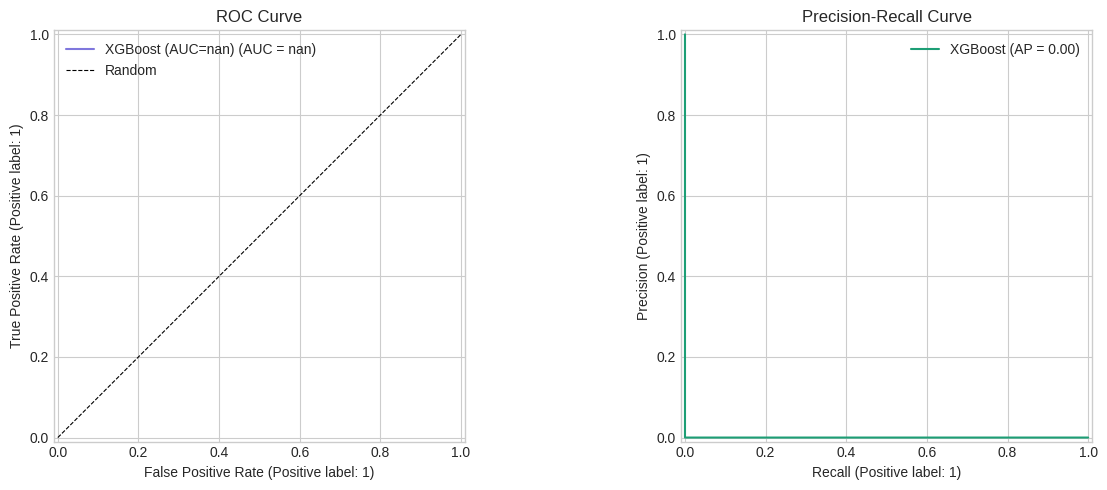

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
RocCurveDisplay.from_predictions(
    y_holdout, y_prob, name=f'XGBoost (AUC={auc})',
    color='#7F77DD', ax=axes[0])
axes[0].plot([0,1],[0,1],'k--',lw=0.8,label='Random')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(
    y_holdout, y_prob, name='XGBoost',
    color='#1D9E75', ax=axes[1])
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()


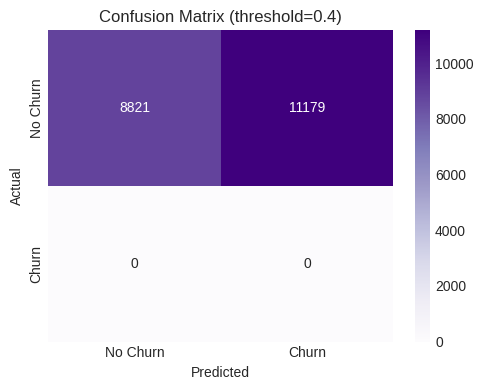

True Positives  (caught churners)  : 0
False Negatives (missed churners)  : 0
False Positives (wrong alarms)     : 11179
True Negatives  (correct no-churn) : 8821


In [5]:
cm = confusion_matrix(y_holdout, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
ax.set_title(f'Confusion Matrix (threshold={THRESHOLD})')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

tn,fp,fn,tp = cm.ravel()
print(f"True Positives  (caught churners)  : {tp}")
print(f"False Negatives (missed churners)  : {fn}")
print(f"False Positives (wrong alarms)     : {fp}")
print(f"True Negatives  (correct no-churn) : {tn}")

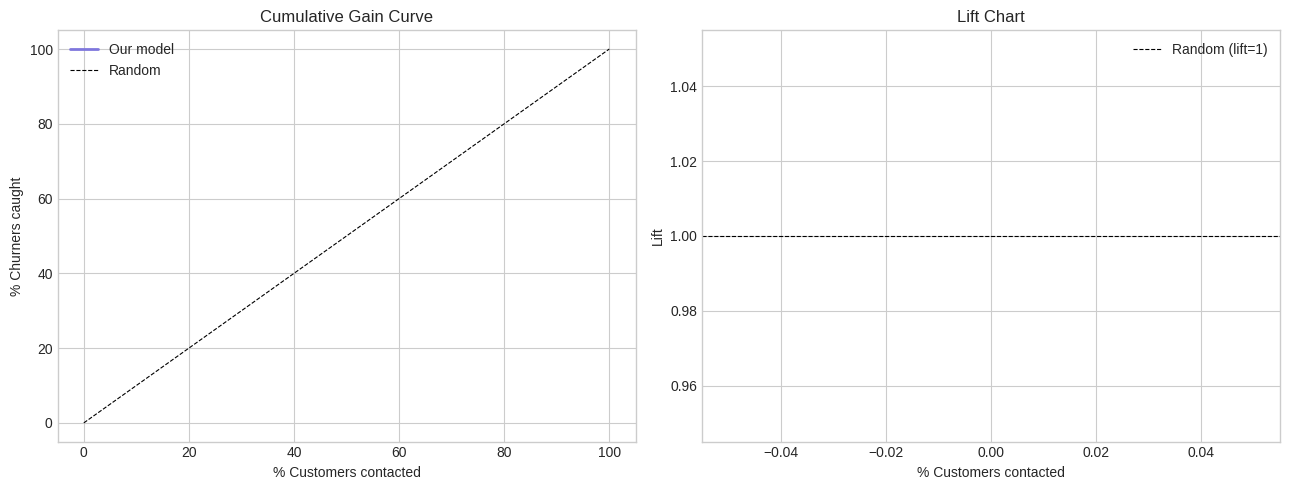

Top 10% customers → catches nan% of all churners
Top 20% customers → catches nan% of all churners
Top 30% customers → catches nan% of all churners
Top 50% customers → catches nan% of all churners


In [6]:
# Lift curve shows: if we contact top X% of customers,
# what % of all churners do we catch?
df_lift = pd.DataFrame({
    'y_true': y_holdout.values,
    'y_prob': y_prob
}).sort_values('y_prob', ascending=False).reset_index(drop=True)

total_churners = df_lift['y_true'].sum()
df_lift['cum_churners']  = df_lift['y_true'].cumsum()
df_lift['pct_customers'] = (df_lift.index + 1) / len(df_lift) * 100
df_lift['pct_churners']  = df_lift['cum_churners'] / total_churners * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Cumulative gain curve
axes[0].plot(df_lift['pct_customers'], df_lift['pct_churners'],
             color='#7F77DD', lw=2, label='Our model')
axes[0].plot([0,100],[0,100], 'k--', lw=0.8, label='Random')
axes[0].fill_between(df_lift['pct_customers'],
                      df_lift['pct_churners'],
                      df_lift['pct_customers'],
                      alpha=0.1, color='#7F77DD')
axes[0].set_xlabel('% Customers contacted')
axes[0].set_ylabel('% Churners caught')
axes[0].set_title('Cumulative Gain Curve')
axes[0].legend()

# Lift chart
df_lift['lift'] = df_lift['pct_churners'] / df_lift['pct_customers']
axes[1].plot(df_lift['pct_customers'], df_lift['lift'],
             color='#1D9E75', lw=2)
axes[1].axhline(1, color='k', linestyle='--', lw=0.8, label='Random (lift=1)')
axes[1].set_xlabel('% Customers contacted')
axes[1].set_ylabel('Lift')
axes[1].set_title('Lift Chart')
axes[1].legend()

plt.tight_layout()
plt.show()

# Print key numbers
for pct in [10, 20, 30, 50]:
    idx = int(len(df_lift) * pct / 100)
    caught = df_lift['pct_churners'].iloc[idx]
    print(f"Top {pct}% customers → catches {caught:.1f}% of all churners")

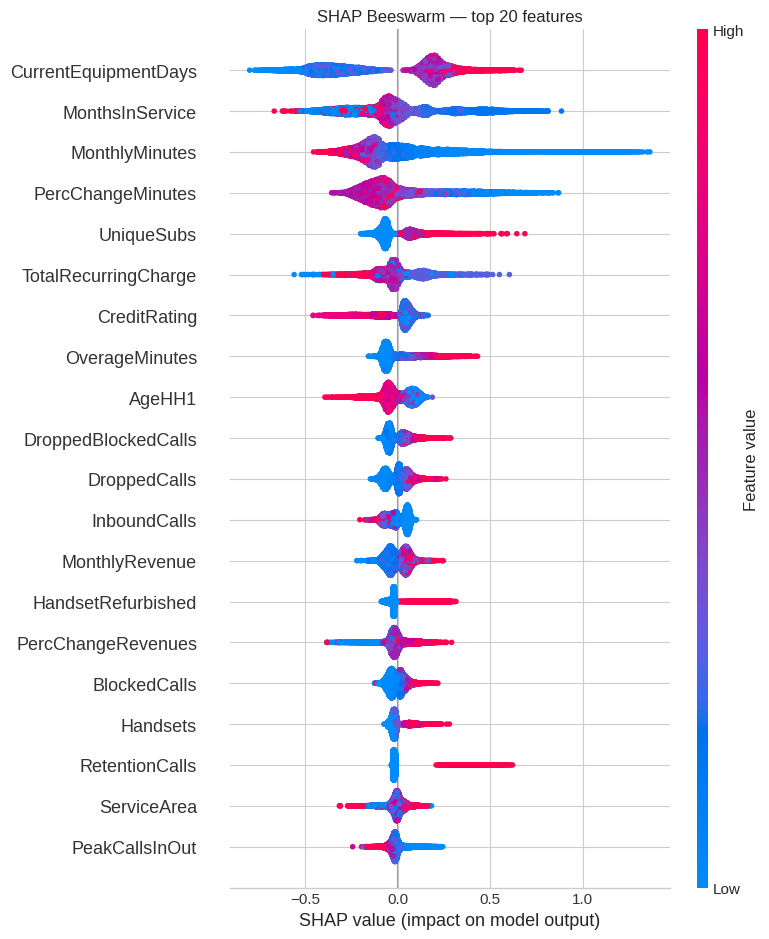

In [7]:
# Install if needed: pip install shap
explainer  = shap.TreeExplainer(model)
shap_vals  = explainer.shap_values(X_holdout)

# Beeswarm — shows direction + magnitude of each feature
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_holdout, plot_type='dot',
                   max_display=20, show=False)
plt.title('SHAP Beeswarm — top 20 features')
plt.tight_layout()
plt.show()

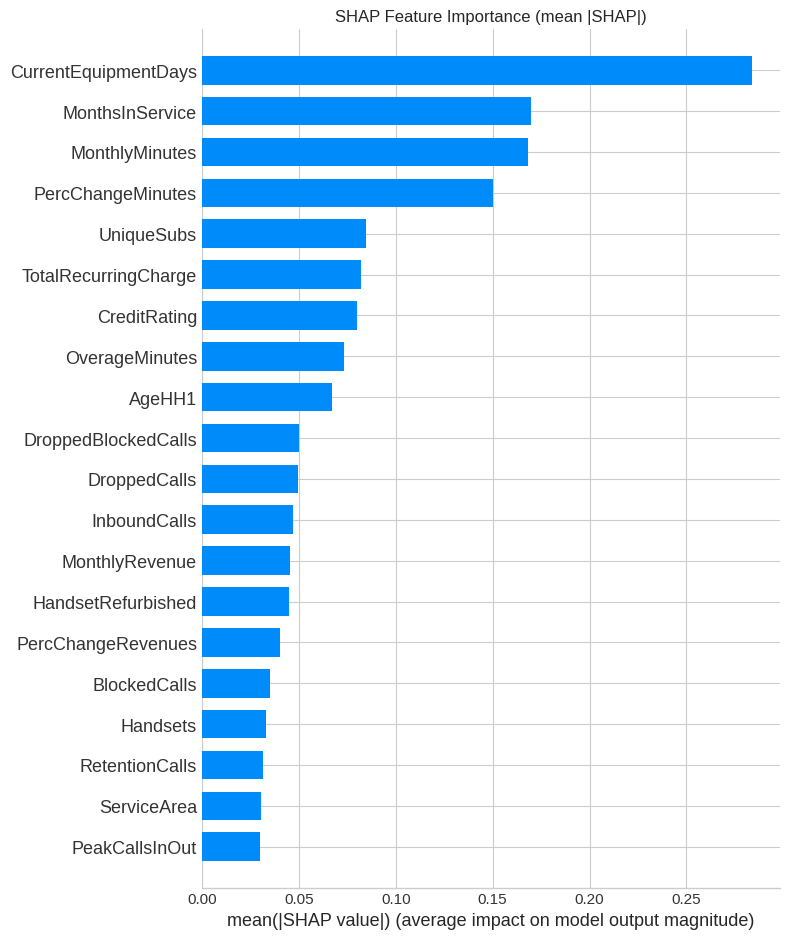

In [8]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_holdout, plot_type='bar',
                   max_display=20, show=False)
plt.title('SHAP Feature Importance (mean |SHAP|)')
plt.tight_layout()
plt.show()

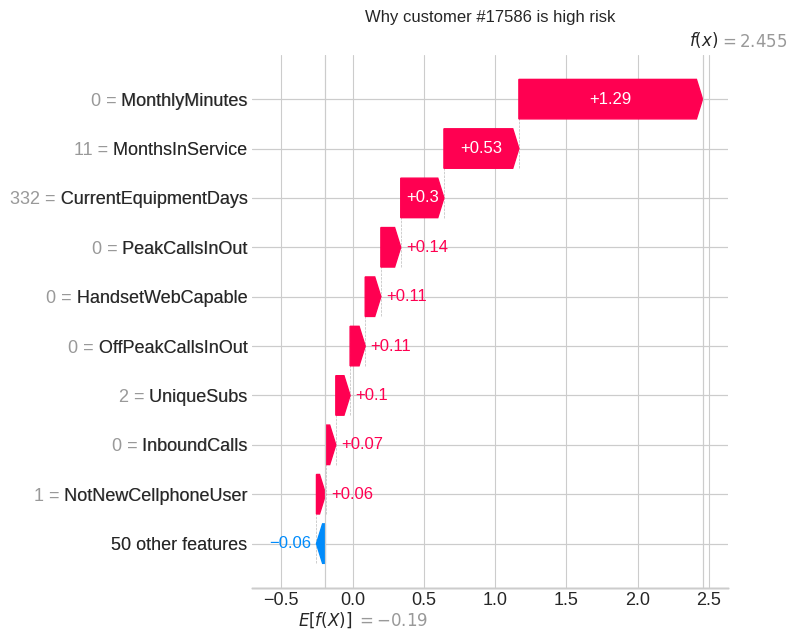

Churn probability: 0.921
Actual label     : Stayed


In [9]:
# Explain a single high-risk customer prediction
shap_explanation = explainer(X_holdout)

# Pick the customer with highest churn probability
high_risk_idx = np.argmax(y_prob)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation[high_risk_idx], show=False)
plt.title(f'Why customer #{high_risk_idx} is high risk')
plt.tight_layout()
plt.show()

print(f"Churn probability: {y_prob[high_risk_idx]:.3f}")
print(f"Actual label     : {'Churned' if y_holdout.iloc[high_risk_idx]==1 else 'Stayed'}")

In [10]:
# Business assumptions — adjust to your scenario
AVG_CUSTOMER_LTV     = 500   # avg revenue per customer ($)
RETENTION_OFFER_COST = 30    # cost of discount/offer per customer ($)
RETENTION_SUCCESS    = 0.35  # 35% of flagged churners accept offer
TOTAL_CUSTOMERS      = 71047 # full Cell2Cell base

# From confusion matrix
tn, fp, fn, tp = confusion_matrix(y_holdout, y_pred).ravel()

# Revenue saved by catching true churners
revenue_saved = tp * RETENTION_SUCCESS * AVG_CUSTOMER_LTV

# Cost of retention offers sent (TP + FP)
offer_cost = (tp + fp) * RETENTION_OFFER_COST

# Net benefit
net_benefit = revenue_saved - offer_cost

# Without model — random 20% contact
random_contact  = int(TOTAL_CUSTOMERS * 0.20)
random_tp       = int(random_contact * (y_holdout.mean()))
random_saved    = random_tp * RETENTION_SUCCESS * AVG_CUSTOMER_LTV
random_cost     = random_contact * RETENTION_OFFER_COST
random_net      = random_saved - random_cost

print("="*45)
print("  BUSINESS IMPACT REPORT")
print("="*45)
print(f"  Churners caught (TP)    : {tp}")
print(f"  Revenue saved           : ${revenue_saved:,.0f}")
print(f"  Offer cost              : ${offer_cost:,.0f}")
print(f"  Net benefit (model)     : ${net_benefit:,.0f}")
print(f"  Net benefit (random)    : ${random_net:,.0f}")
print(f"  Incremental gain        : ${net_benefit - random_net:,.0f}")
print("="*45)

  BUSINESS IMPACT REPORT
  Churners caught (TP)    : 0
  Revenue saved           : $0
  Offer cost              : $335,370
  Net benefit (model)     : $-335,370
  Net benefit (random)    : $-426,270
  Incremental gain        : $90,900


In [2]:
import os
from sklearn.metrics import roc_auc_score
os.makedirs('../data/processed', exist_ok=True)

report = {
    'holdout_auc'      : round(roc_auc_score(y_holdout, y_prob), 4),
    'threshold'        : THRESHOLD,
    'true_positives'   : int(tp),
    'false_positives'  : int(fp),
    'false_negatives'  : int(fn),
    'true_negatives'   : int(tn),
    'revenue_saved'    : round(revenue_saved, 2),
    'offer_cost'       : round(offer_cost, 2),
    'net_benefit'      : round(net_benefit, 2),
    'incremental_gain' : round(net_benefit - random_net, 2),
}

with open('../data/processed/evaluation_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print("Evaluation report saved!")
print(json.dumps(report, indent=2))

NameError: name 'y_holdout' is not defined